# A/B Test: Checkout Free Shipping Banner
## Stage 3b: Statistical Analysis and Product Recommendation

This notebook runs the formal statistical tests on the experiment results and produces a product recommendation.

| | Control | Treatment |
|---|---|---|
| **Orders** | 235 | 228 |
| **AOV (raw)** | £88.41 | £87.92 |
| **Conversion rate (raw)** | 73.2% | 74.1% |
| **Return rate (raw)** | 26.8% | 25.9% |

Raw differences observed in EDA: AOV lift of **negative £0.49** and conversion rate lift of **+0.9 percentage points**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from google.cloud import bigquery

BACKGROUND = '#DDDCD6'
TEAL       = '#0D9488'
PURPLE     = '#6B21A8'
SIG_COLOR  = '#16A34A'   # green: significant
INSIG_COLOR= '#94A3B8'   # grey: not significant

ALPHA = 0.05   # significance level

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
})

## 1. Load experiment results

In [2]:
client = bigquery.Client(project='dbt-portfolio-498511')

df = client.query("""
    select
        order_id, user_id, variant,
        order_value, is_completed, is_returned
    from `dbt-portfolio-498511.dbt_analytics.fct_experiment_results`
""").to_dataframe()

control   = df[df['variant'] == 'control']
treatment = df[df['variant'] == 'treatment']

print(f'Control:   {len(control):,} orders')
print(f'Treatment: {len(treatment):,} orders')

Control:   235 orders
Treatment: 228 orders


## 2. Test 1: Conversion rate

**Method:** Two-proportion z-test (two-tailed)  
**H0:** Conversion rate is the same in both variants  
**H1:** Conversion rate differs between variants  
**Alpha:** 0.05

In [3]:
n_control   = len(control)
n_treatment = len(treatment)
c_control   = control['is_completed'].sum()
c_treatment = treatment['is_completed'].sum()

p_control   = c_control   / n_control
p_treatment = c_treatment / n_treatment

z_stat, p_value_conv = proportions_ztest(
    [c_control, c_treatment],
    [n_control, n_treatment],
    alternative='two-sided'
)

# 95% confidence intervals on each rate
ci_control   = proportion_confint(c_control,   n_control,   alpha=ALPHA, method='wilson')
ci_treatment = proportion_confint(c_treatment, n_treatment, alpha=ALPHA, method='wilson')

print('=== Conversion Rate ===')
print(f'Control:   {p_control:.1%}  (95% CI: {ci_control[0]:.1%} to {ci_control[1]:.1%})')
print(f'Treatment: {p_treatment:.1%}  (95% CI: {ci_treatment[0]:.1%} to {ci_treatment[1]:.1%})')
print(f'Absolute lift: {p_treatment - p_control:+.1%}')
print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value_conv:.4f}')
print(f'Significant: {p_value_conv < ALPHA}')

=== Conversion Rate ===
Control:   73.2%  (95% CI: 67.2% to 78.4%)
Treatment: 74.1%  (95% CI: 68.1% to 79.4%)
Absolute lift: +0.9%
Z-statistic: -0.2274
P-value: 0.8201
Significant: False


## 3. Test 2: Average order value

**Method:** Welch t-test (two-tailed, does not assume equal variance)  
**H0:** Mean order value is the same in both variants  
**H1:** Mean order value differs between variants  
**Alpha:** 0.05

In [4]:
control_aov   = control['order_value']
treatment_aov = treatment['order_value']

t_stat, p_value_aov = stats.ttest_ind(
    control_aov, treatment_aov,
    equal_var=False   # Welch t-test
)

# 95% confidence interval on the difference
mean_diff = treatment_aov.mean() - control_aov.mean()
se_diff   = np.sqrt(
    control_aov.std()**2 / len(control_aov) +
    treatment_aov.std()**2 / len(treatment_aov)
)
df_welch = (
    (control_aov.std()**2/len(control_aov) + treatment_aov.std()**2/len(treatment_aov))**2
    / (
        (control_aov.std()**2/len(control_aov))**2 / (len(control_aov)-1) +
        (treatment_aov.std()**2/len(treatment_aov))**2 / (len(treatment_aov)-1)
    )
)
t_crit = stats.t.ppf(1 - ALPHA/2, df=df_welch)
ci_aov = (mean_diff - t_crit * se_diff, mean_diff + t_crit * se_diff)

print('=== Average Order Value ===')
print(f'Control mean:   £{control_aov.mean():.2f}  (SD: £{control_aov.std():.2f})')
print(f'Treatment mean: £{treatment_aov.mean():.2f}  (SD: £{treatment_aov.std():.2f})')
print(f'Absolute difference: £{mean_diff:+.2f}')
print(f'95% CI on difference: £{ci_aov[0]:.2f} to £{ci_aov[1]:.2f}')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value_aov:.4f}')
print(f'Significant: {p_value_aov < ALPHA}')

=== Average Order Value ===
Control mean:   £88.41  (SD: £104.59)
Treatment mean: £87.92  (SD: £94.56)
Absolute difference: £-0.49
95% CI on difference: £-18.69 to £17.71
T-statistic: 0.0526
P-value: 0.9580
Significant: False


## 4. Guardrail check: return rate

The experiment should be paused if treatment return rate exceeds control by more than 3 percentage points.

In [5]:
r_control   = control['is_returned'].mean()
r_treatment = treatment['is_returned'].mean()
return_diff = r_treatment - r_control
GUARDRAIL   = 0.03

print('=== Guardrail: Return Rate ===')
print(f'Control:   {r_control:.1%}')
print(f'Treatment: {r_treatment:.1%}')
print(f'Difference: {return_diff:+.1%}')
print(f'Guardrail breached (>{GUARDRAIL:.0%} increase): {return_diff > GUARDRAIL}')

=== Guardrail: Return Rate ===
Control:   26.8%
Treatment: 25.9%
Difference: -0.9%
Guardrail breached (>3% increase): False


## 5. Results visualisation

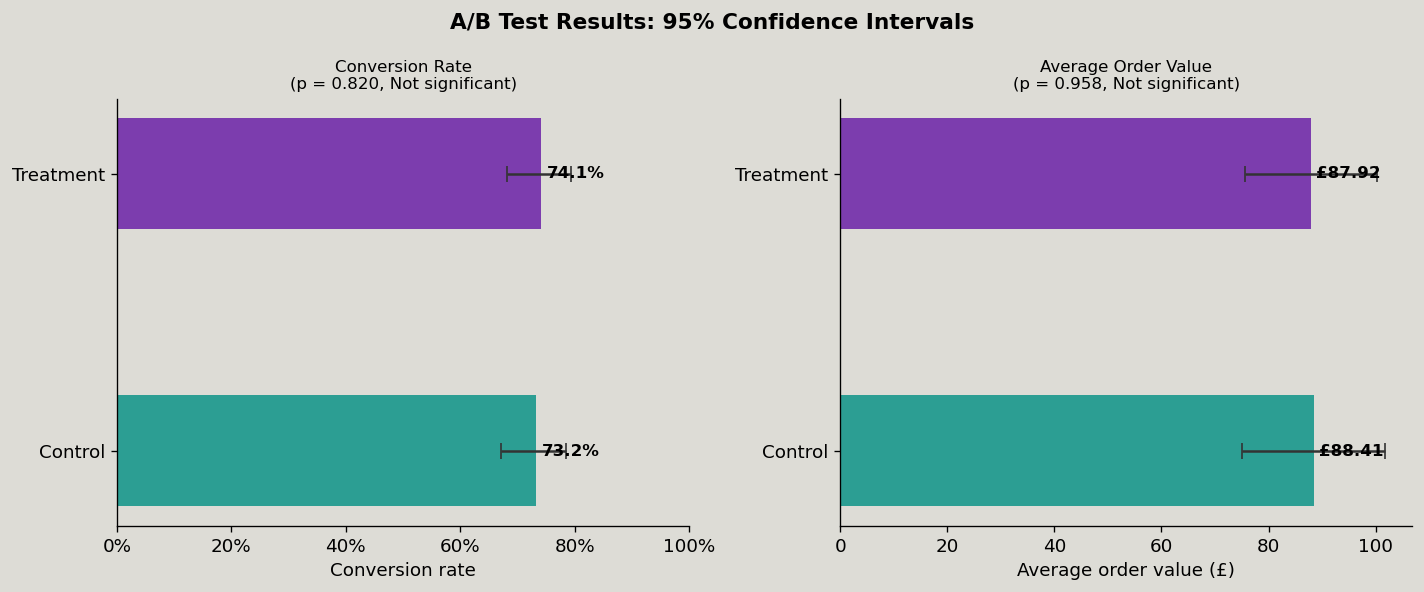

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.set_facecolor(BACKGROUND)
fig.suptitle('A/B Test Results: 95% Confidence Intervals', fontsize=13, fontweight='bold')

# --- Conversion rate CI plot ---
ax = axes[0]
ax.set_facecolor(BACKGROUND)
variants = ['Control', 'Treatment']
rates    = [p_control, p_treatment]
cis      = [ci_control, ci_treatment]
colors   = [TEAL, PURPLE]

for i, (v, r, ci, c) in enumerate(zip(variants, rates, cis, colors)):
    ax.barh(i, r, height=0.4, color=c, alpha=0.85)
    ax.errorbar(r, i, xerr=[[r - ci[0]], [ci[1] - r]],
                fmt='none', color='#333333', capsize=5, linewidth=1.5)
    ax.text(r + 0.01, i, f'{r:.1%}', va='center', fontsize=10, fontweight='bold')

ax.set_yticks([0, 1])
ax.set_yticklabels(variants)
ax.set_xlabel('Conversion rate')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_xlim(0, 1)
sig_label = 'Significant' if p_value_conv < ALPHA else 'Not significant'
ax.set_title(f'Conversion Rate\n(p = {p_value_conv:.3f}, {sig_label})', fontsize=10)

# --- AOV CI plot ---
ax2 = axes[1]
ax2.set_facecolor(BACKGROUND)
means = [control_aov.mean(), treatment_aov.mean()]
stderrs = [control_aov.sem(), treatment_aov.sem()]

for i, (v, m, se, c) in enumerate(zip(variants, means, stderrs, colors)):
    ci_lo = m - 1.96 * se
    ci_hi = m + 1.96 * se
    ax2.barh(i, m, height=0.4, color=c, alpha=0.85)
    ax2.errorbar(m, i, xerr=[[m - ci_lo], [ci_hi - m]],
                 fmt='none', color='#333333', capsize=5, linewidth=1.5)
    ax2.text(m + 1, i, f'£{m:.2f}', va='center', fontsize=10, fontweight='bold')

ax2.set_yticks([0, 1])
ax2.set_yticklabels(variants)
ax2.set_xlabel('Average order value (£)')
sig_label2 = 'Significant' if p_value_aov < ALPHA else 'Not significant'
ax2.set_title(f'Average Order Value\n(p = {p_value_aov:.3f}, {sig_label2})', fontsize=10)

plt.tight_layout()
plt.savefig('../images/statistical_results.png', facecolor=BACKGROUND, bbox_inches='tight')
plt.show()

## 6. Product recommendation

### Verdict: Inconclusive. Do not roll out.

Neither the conversion rate lift (+0.9 percentage points, p >> 0.05) nor the AOV difference (negative £0.49, p >> 0.05) reached statistical significance. The guardrail metric is safe: treatment return rate did not exceed control by more than 3 percentage points.

However, the inconclusive result is not primarily because the banner had no effect. It is because the experiment is **massively underpowered**. The power calculation in the experiment design document established that detecting a 5% AOV lift (the minimum business-meaningful effect) would require approximately 7,494 orders per variant (14,988 total). The test window captured only 463 orders in total, giving the experiment roughly **3% statistical power** rather than the target 80%.

Put simply: the experiment cannot reliably detect an effect of the size we care about, even if one exists.

### What this means in practice

This is not a failure of the banner design. It is a traffic problem. At roughly 12 completed orders per day across the full dataset, reaching the required sample size would take over 1,200 days of live testing. On a real production e-commerce platform with thousands of daily orders, the same test would reach significance in 3 to 4 weeks.

### Recommended next steps

1. Do not draw conclusions about banner effectiveness from this test.
2. If this were a live product, run the experiment on production traffic with a minimum of 7,500 orders per variant before making a rollout decision.
3. Consider whether a 5% AOV lift is the right minimum detectable effect, or whether a larger effect (10 to 15%) would still be business-meaningful. A higher MDE reduces the required sample size significantly.
4. Monitor the guardrail metric (return rate) throughout any future live test, particularly in the first two weeks.